# Wine Quality Prediction
## Oasis Infobyte — Data Analytics Internship
### Name: Priti Ranjit | Track: Data Analytics | Level 2 Task 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
df = pd.read_csv('winequality-red.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1599, 12)

First 5 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Step 1: Data Inspection

In [3]:
print("Column Names:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nClass Distribution of Quality:")
print(df['quality'].value_counts().sort_index())

Column Names: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Data Types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Missing Values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Class Distribution of Quality:
quality
3     10
4

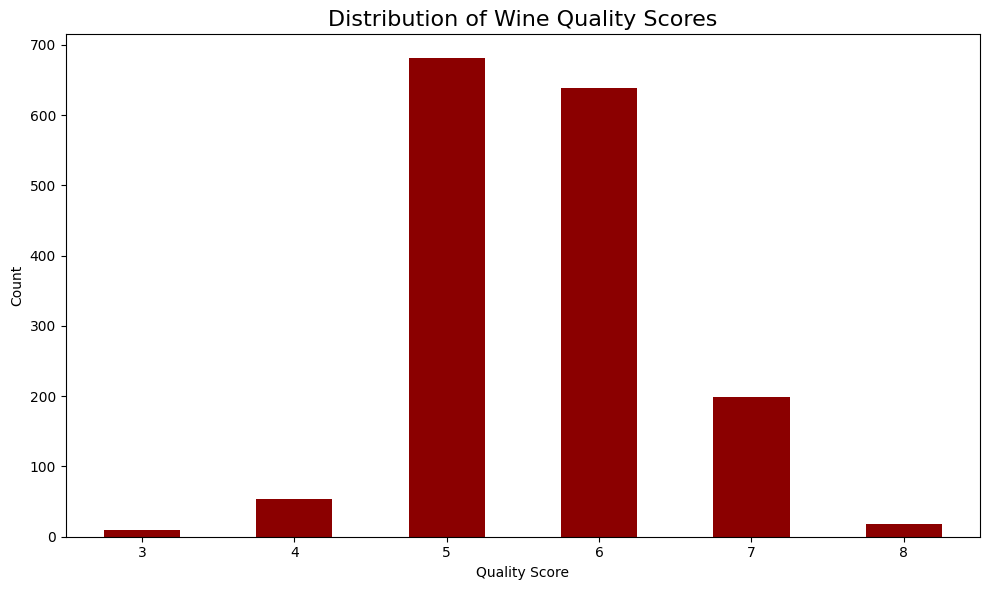

In [4]:
plt.figure(figsize=(10, 6))
df['quality'].value_counts().sort_index().plot(kind='bar', color='darkred')
plt.title('Distribution of Wine Quality Scores', fontsize=16)
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('quality_distribution.png')
plt.show()

## Step 2: EDA — Chemical Feature Distributions

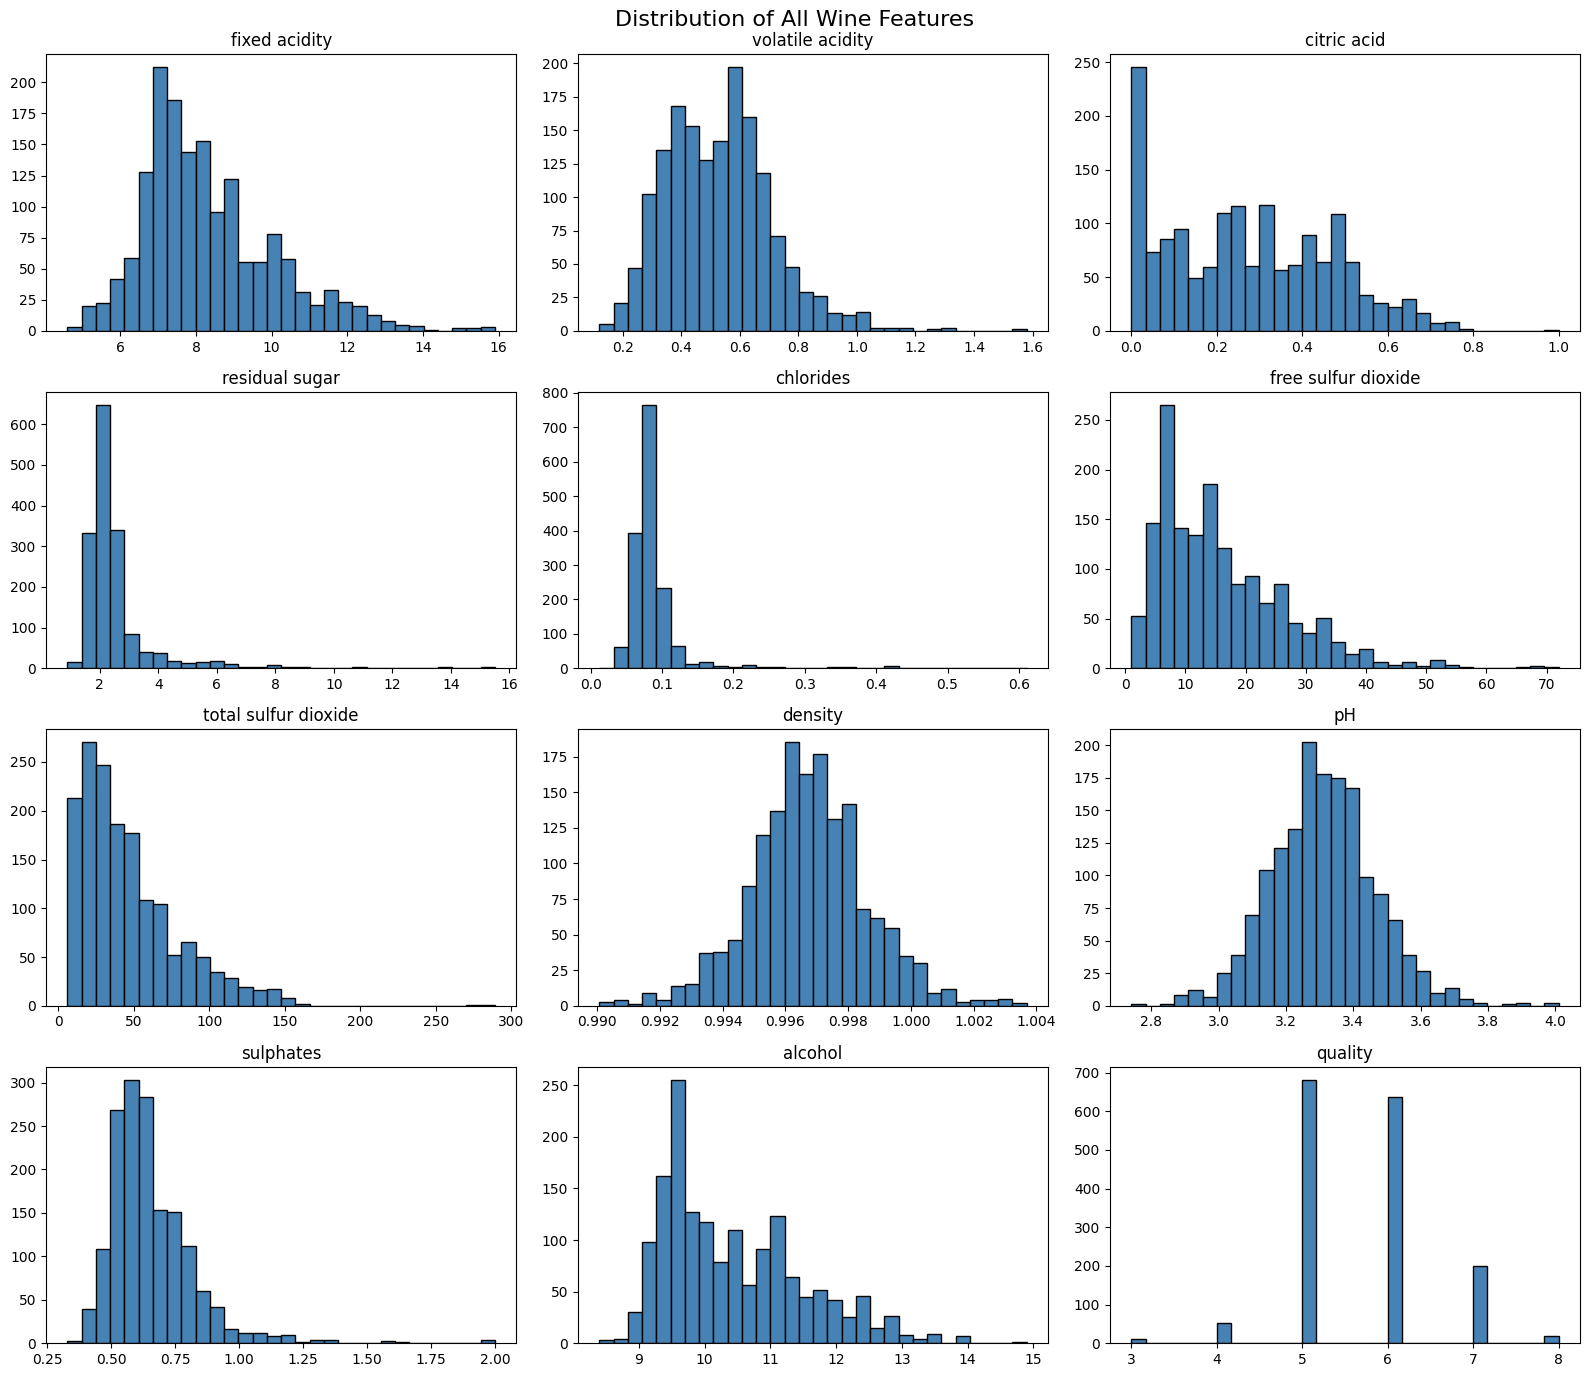

In [5]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Distribution of All Wine Features', fontsize=16)
plt.tight_layout()
plt.savefig('feature_distributions.png')
plt.show()

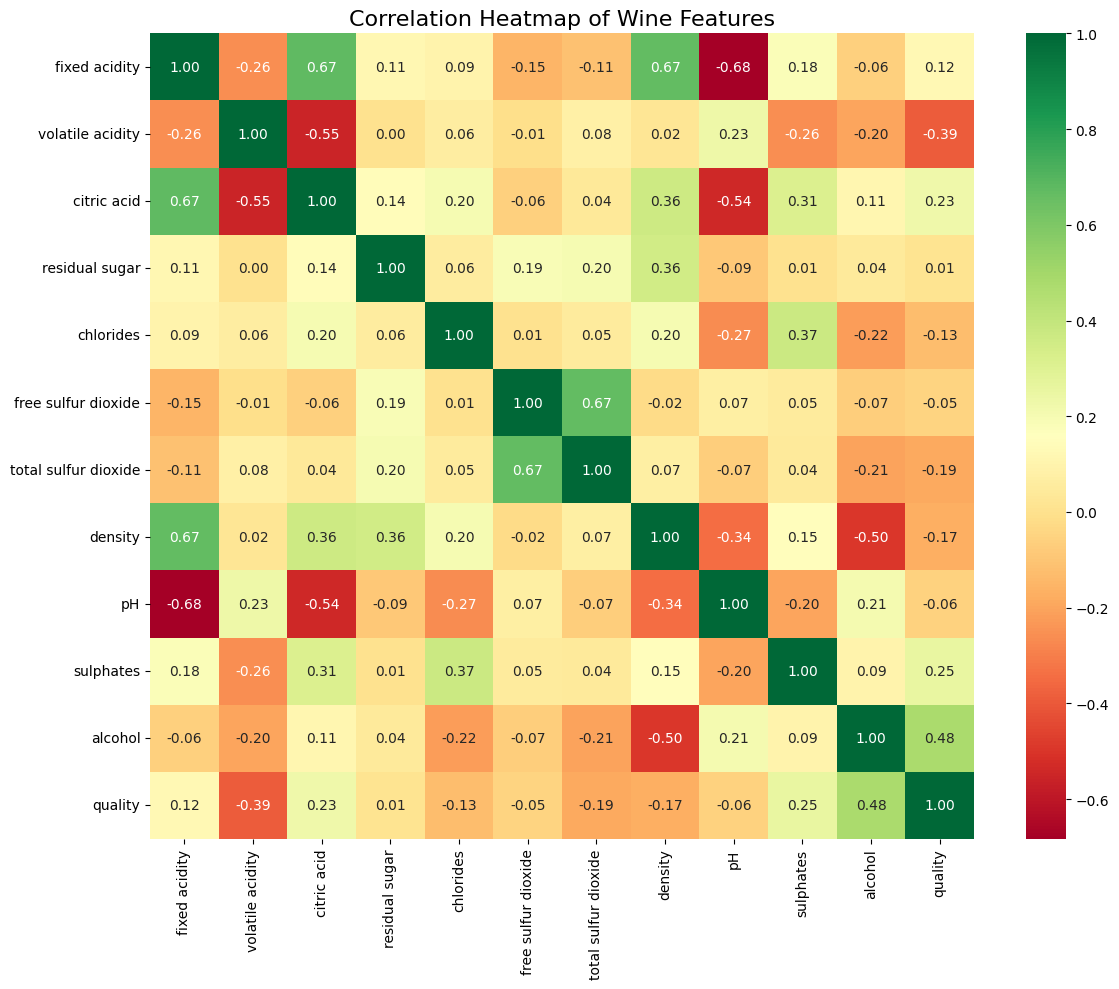

In [6]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation Heatmap of Wine Features', fontsize=16)
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

## Step 3: Feature Engineering
We bin quality scores into 3 classes:
- Low: quality 3-4
- Medium: quality 5-6  
- High: quality 7-8

Class Distribution after binning:
quality_label
Medium    1319
High       217
Low         63
Name: count, dtype: int64


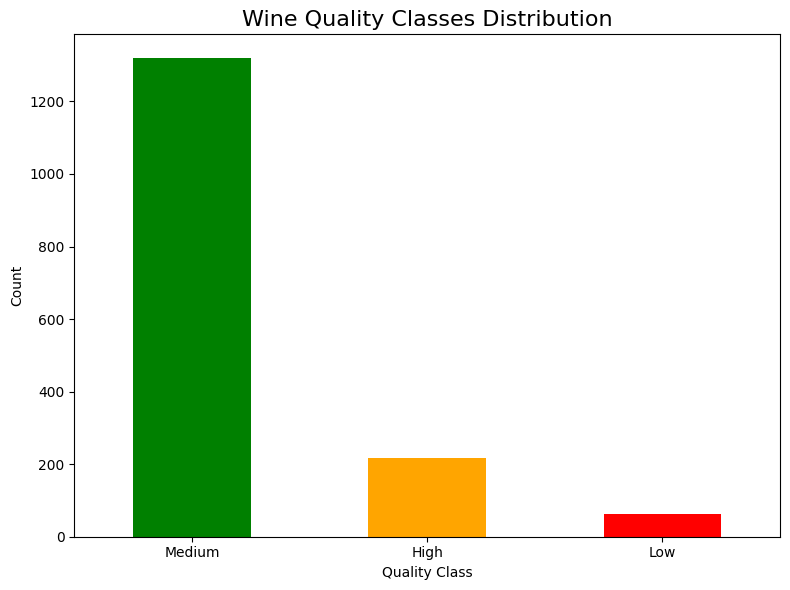

In [7]:
def quality_label(q):
    if q <= 4:
        return 'Low'
    elif q <= 6:
        return 'Medium'
    else:
        return 'High'

df['quality_label'] = df['quality'].apply(quality_label)

print("Class Distribution after binning:")
print(df['quality_label'].value_counts())

plt.figure(figsize=(8, 6))
df['quality_label'].value_counts().plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Wine Quality Classes Distribution', fontsize=16)
plt.xlabel('Quality Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('quality_classes.png')
plt.show()

## Step 4: Data Preprocessing

In [8]:
X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature matrix shape:", X_scaled.shape)
print("Target classes:", y.unique())

Feature matrix shape: (1599, 11)
Target classes: <StringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str


## Step 5: Train/Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, 
    random_state=42, stratify=y
)

print("Training size:", X_train.shape[0])
print("Testing size:", X_test.shape[0])

Training size: 1279
Testing size: 320


## Step 6: Train 3 Classification Models

In [10]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

print("Random Forest trained!")
print("Accuracy:", accuracy_score(y_test, rf_predictions))

Random Forest trained!
Accuracy: 0.86875


In [11]:
sgd_model = SGDClassifier(random_state=42, max_iter=1000)
sgd_model.fit(X_train, y_train)
sgd_predictions = sgd_model.predict(X_test)

print("SGD Classifier trained!")
print("Accuracy:", accuracy_score(y_test, sgd_predictions))

SGD Classifier trained!
Accuracy: 0.828125


In [12]:
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)
svm_predictions = svm_model.predict(X_test)

print("SVM Classifier trained!")
print("Accuracy:", accuracy_score(y_test, svm_predictions))

SVM Classifier trained!
Accuracy: 0.84375


## Step 7: Model Evaluation

In [13]:
models = {
    'Random Forest': rf_predictions,
    'SGD Classifier': sgd_predictions,
    'SVM Classifier': svm_predictions
}

print("MODEL EVALUATION RESULTS")
print("="*60)

for model_name, predictions in models.items():
    acc = accuracy_score(y_test, predictions)
    print(f"\n{model_name}")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, predictions))

MODEL EVALUATION RESULTS

Random Forest
Accuracy: 0.8688
              precision    recall  f1-score   support

        High       0.72      0.53      0.61        43
         Low       0.00      0.00      0.00        13
      Medium       0.89      0.97      0.92       264

    accuracy                           0.87       320
   macro avg       0.53      0.50      0.51       320
weighted avg       0.83      0.87      0.84       320


SGD Classifier
Accuracy: 0.8281
              precision    recall  f1-score   support

        High       0.55      0.14      0.22        43
         Low       0.00      0.00      0.00        13
      Medium       0.84      0.98      0.90       264

    accuracy                           0.83       320
   macro avg       0.46      0.37      0.38       320
weighted avg       0.76      0.83      0.78       320


SVM Classifier
Accuracy: 0.8438
              precision    recall  f1-score   support

        High       0.64      0.33      0.43        43
      

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

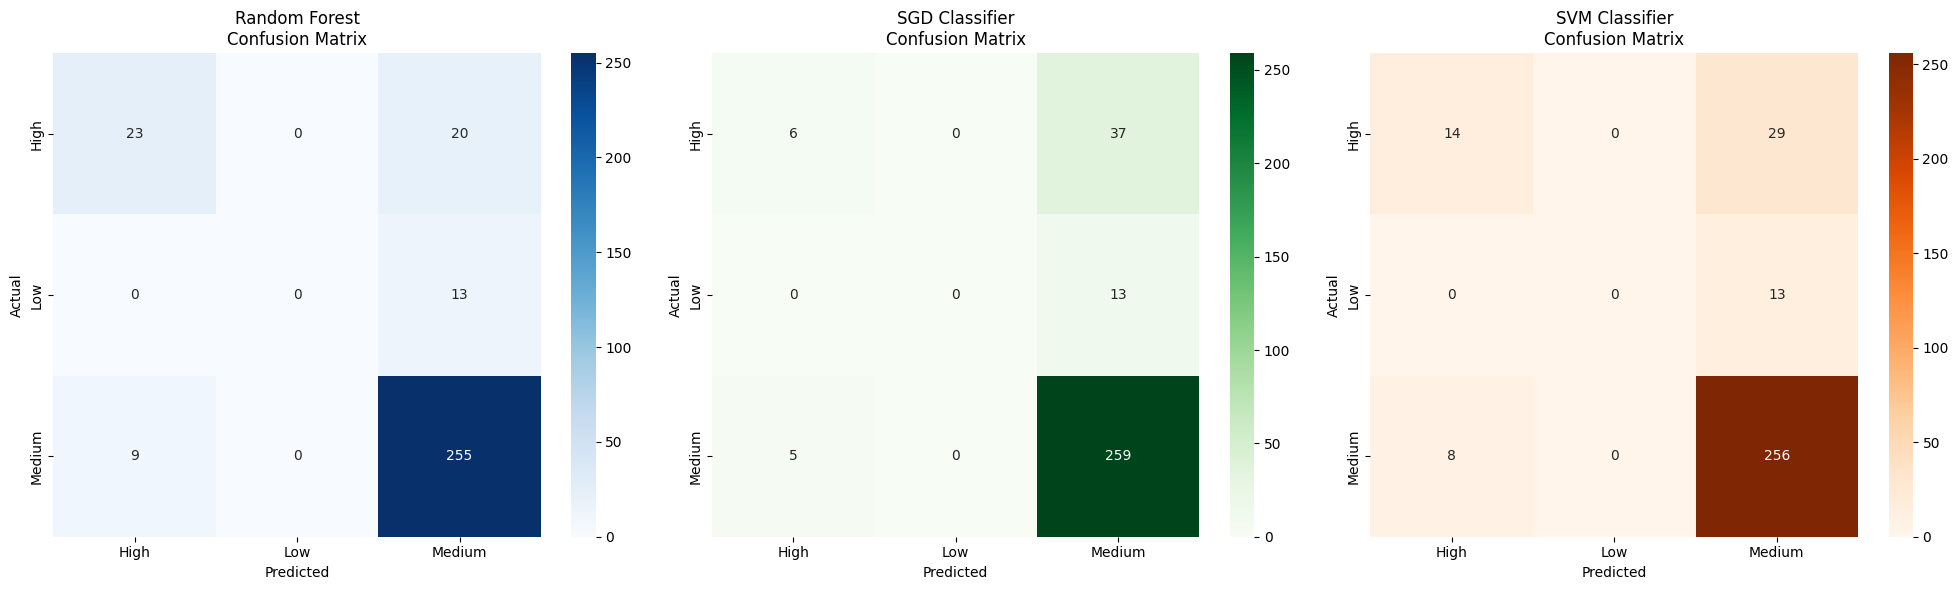

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

model_names = ['Random Forest', 'SGD Classifier', 'SVM Classifier']
predictions_list = [rf_predictions, sgd_predictions, svm_predictions]
colors = ['Blues', 'Greens', 'Oranges']

for i, (name, preds) in enumerate(zip(model_names, predictions_list)):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', 
                cmap=colors[i], ax=axes[i],
                xticklabels=['High', 'Low', 'Medium'],
                yticklabels=['High', 'Low', 'Medium'])
    axes[i].set_title(f'{name}\nConfusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png')
plt.show()

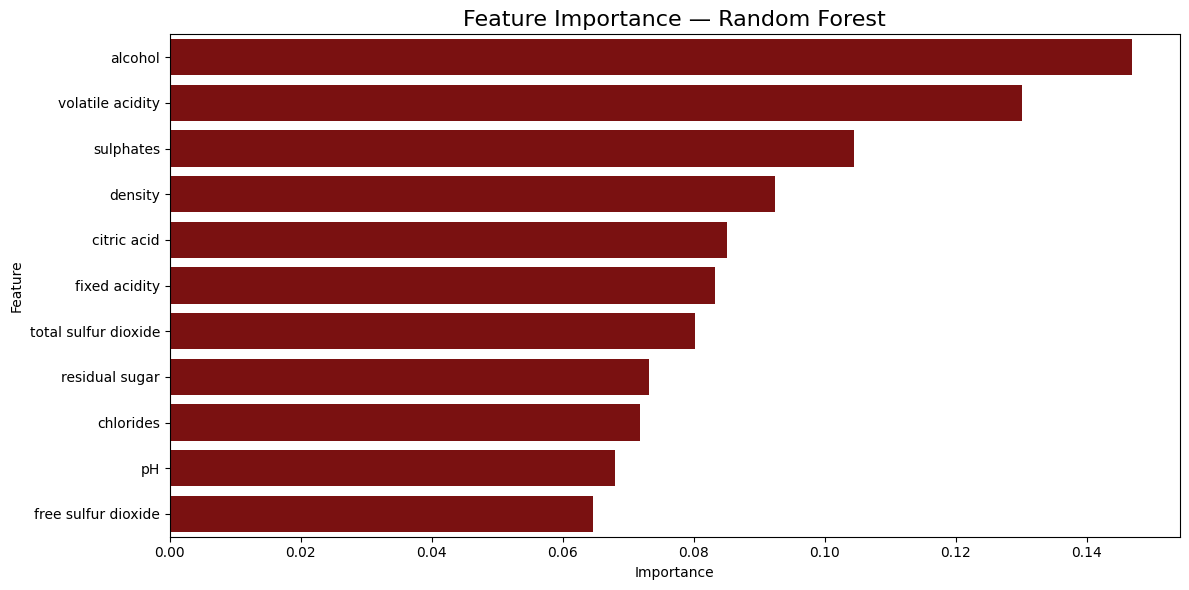

                 Feature  Importance
10               alcohol    0.146866
1       volatile acidity    0.130046
9              sulphates    0.104467
7                density    0.092413
2            citric acid    0.085064
0          fixed acidity    0.083301
6   total sulfur dioxide    0.080194
3         residual sugar    0.073206
4              chlorides    0.071864
8                     pH    0.067959
5    free sulfur dioxide    0.064619


In [15]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', 
            data=feature_importance, color='darkred')
plt.title('Feature Importance — Random Forest', fontsize=16)
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print(feature_importance)

In [16]:
comparison = pd.DataFrame({
    'Model': list(models.keys()),
    'Accuracy': [accuracy_score(y_test, p) for p in models.values()]
}).sort_values('Accuracy', ascending=False)

print("MODEL COMPARISON TABLE")
print("="*40)
print(comparison.to_string(index=False))

MODEL COMPARISON TABLE
         Model  Accuracy
 Random Forest  0.868750
SVM Classifier  0.843750
SGD Classifier  0.828125


## Conclusion

### Key Findings:
1. **Alcohol content** is the most important feature for 
   predicting wine quality — higher alcohol generally 
   indicates better quality wine
2. **Volatile acidity** negatively impacts quality — 
   high levels lead to unpleasant vinegar taste
3. **Sulphates** positively contribute to wine quality

### Model Performance:
- **Random Forest** performed best overall — it handles 
  non-linear relationships and feature interactions well
- **SVM** performed well with the RBF kernel
- **SGD** was fastest to train but less accurate

### Class Imbalance Observation:
The dataset has far more Medium quality wines than Low or 
High — this affects model performance on minority classes. 
Future work could use SMOTE oversampling to balance classes.

### Best Model for Deployment:
Random Forest is the most suitable model due to its 
highest accuracy, interpretability through feature 
importance, and robustness to outliers.